In [3]:
!pip install -q catboost

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    ConfusionMatrixDisplay
)
df = pd.read_csv("CKD_preprocessed_patient_level.csv")
TARGET = "CKD (1-yes, 0-no)"

if TARGET not in df.columns:
    raise ValueError(f"Target column '{TARGET}' not found.")
if "Patient ID" in df.columns:
    raise ValueError("Patient ID is still present. Remove before modeling.")
if df.isnull().sum().sum() > 0:
    raise ValueError("Missing values detected in the dataset.")

X = df.drop(columns=[TARGET])
y = df[TARGET].astype(int)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=42
)
print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))

model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="AUC",
    l2_leaf_reg=3,
    random_strength=1,
    random_seed=42,
    verbose=False,
    allow_writing_files=False
)

Training samples: 280
Testing samples : 120



CATBOOST RESULTS
Accuracy    : 0.8000
Precision   : 0.7818
Recall      : 0.7818
Specificity : 0.8154
F1 Score    : 0.7818
ROC-AUC     : 0.8487
PR-AUC      : 0.8343

Confusion Matrix:
[[53 12]
 [12 43]]

Classification Report:
              precision    recall  f1-score   support

      No CKD       0.82      0.82      0.82        65
         CKD       0.78      0.78      0.78        55

    accuracy                           0.80       120
   macro avg       0.80      0.80      0.80       120
weighted avg       0.80      0.80      0.80       120



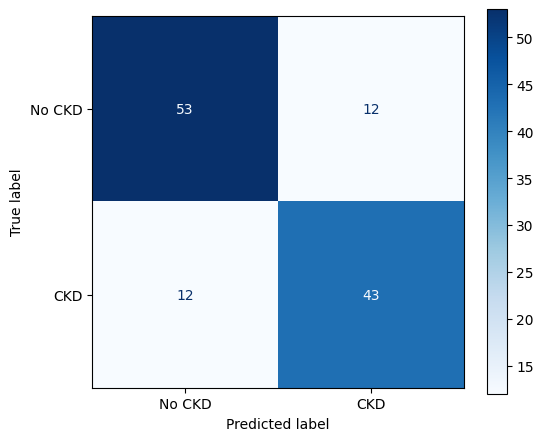

In [6]:
model.fit(X_train, y_train, verbose=False)

y_pred = model.predict(X_test).astype(int).ravel()
y_prob = model.predict_proba(X_test)[:, 1]

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy    = accuracy_score(y_test, y_pred)
precision   = precision_score(y_test, y_pred, zero_division=0)
recall      = recall_score(y_test, y_pred, zero_division=0)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
f1          = f1_score(y_test, y_pred, zero_division=0)
roc_auc     = roc_auc_score(y_test, y_prob)
pr_auc      = average_precision_score(y_test, y_prob)

print("\n" + "=" * 60)
print("CATBOOST RESULTS")
print("=" * 60)
print(f"Accuracy    : {accuracy:.4f}")
print(f"Precision   : {precision:.4f}")
print(f"Recall      : {recall:.4f}")
print(f"Specificity : {specificity:.4f}")
print(f"F1 Score    : {f1:.4f}")
print(f"ROC-AUC     : {roc_auc:.4f}")
print(f"PR-AUC      : {pr_auc:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
                            target_names=["No CKD", "CKD"], zero_division=0))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["No CKD", "CKD"],
    cmap="Blues", values_format="d", ax=ax
)


<Figure size 640x480 with 0 Axes>

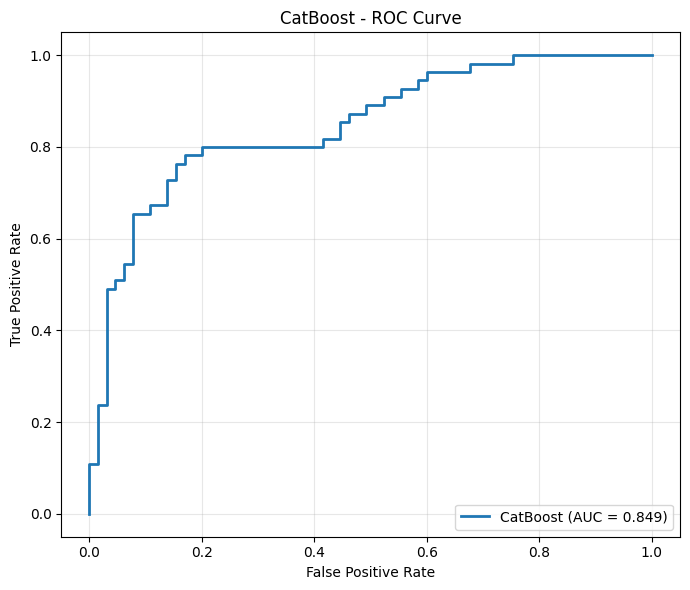

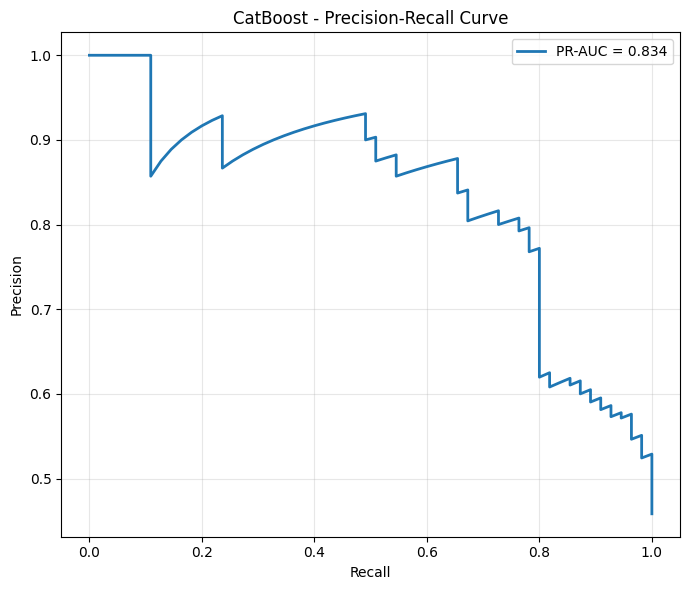

In [7]:
ax.set_title("CatBoost - Confusion Matrix")
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, linewidth=2, label=f"CatBoost (AUC = {roc_auc:.3f})")
ax.plot([0, 1], [0, 1], linestyle="", linewidth=1)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("CatBoost - ROC Curve")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_prob)
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(recall_curve, precision_curve, linewidth=2,
        label=f"PR-AUC = {pr_auc:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("CatBoost - Precision-Recall Curve")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


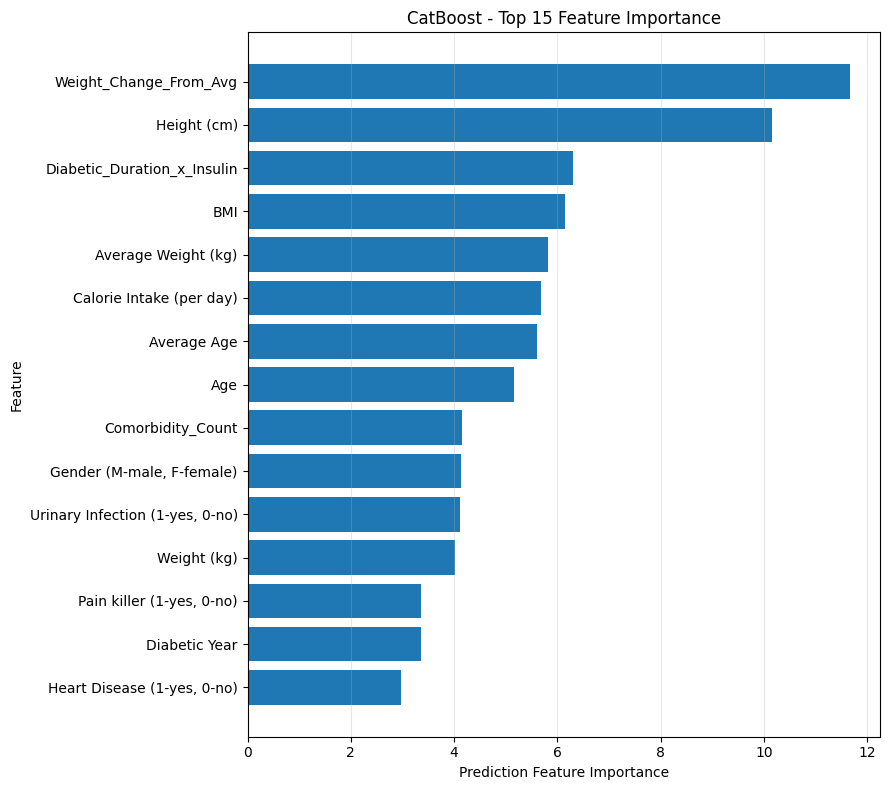


Top 15 CatBoost Features:
                        Feature  Importance
         Weight_Change_From_Avg   11.662233
                    Height (cm)   10.163647
    Diabetic_Duration_x_Insulin    6.293011
                            BMI    6.145749
            Average Weight (kg)    5.821210
       Calorie Intake (per day)    5.687531
                    Average Age    5.604047
                            Age    5.162978
              Comorbidity_Count    4.148801
      Gender (M-male, F-female)    4.134227
Urinary Infection (1-yes, 0-no)    4.116510
                    Weight (kg)    4.013935
      Pain killer (1-yes, 0-no)    3.364494
                  Diabetic Year    3.356564
    Heart Disease (1-yes, 0-no)    2.979953


In [8]:
# FEATURE IMPORTANCE

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.get_feature_importance()
}).sort_values("Importance", ascending=True)

top_features = importance.tail(15)

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(top_features["Feature"], top_features["Importance"])
ax.set_xlabel("Prediction Feature Importance")
ax.set_ylabel("Feature")
ax.set_title("CatBoost - Top 15 Feature Importance")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 15 CatBoost Features:")
print(
    importance
    .sort_values("Importance", ascending=False)
    .head(15)
    .to_string(index=False)
)